In [1]:
%load_ext autoreload
%autoreload 2

## Old and New date

In [1]:
import sys
import os

sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [2]:
from Scripts_Imane import Plots
import pandas as pd 
from Scripts_Imane import gene_self_sim
from scipy.stats import norm


In [3]:
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean.csv')
old = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1.csv')
new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')


/tmp/ipykernel_1615532/2423233899.py:3: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')


In [5]:
(
    old[old['plate'] == 99]
    .groupby('light_regime')['well_id']
    .count()
)



light_regime
10min-10min    383
1min-1min      383
20h_HL         383
20h_ML         383
2h-2h          383
30s-30s        383
Name: well_id, dtype: int64

In [6]:
old[old['plate'] == 99]['light_regime'].unique()

array(['1min-1min', '20h_HL', '20h_ML', '2h-2h', '10min-10min', '30s-30s'],
      dtype=object)

In [8]:
data = new

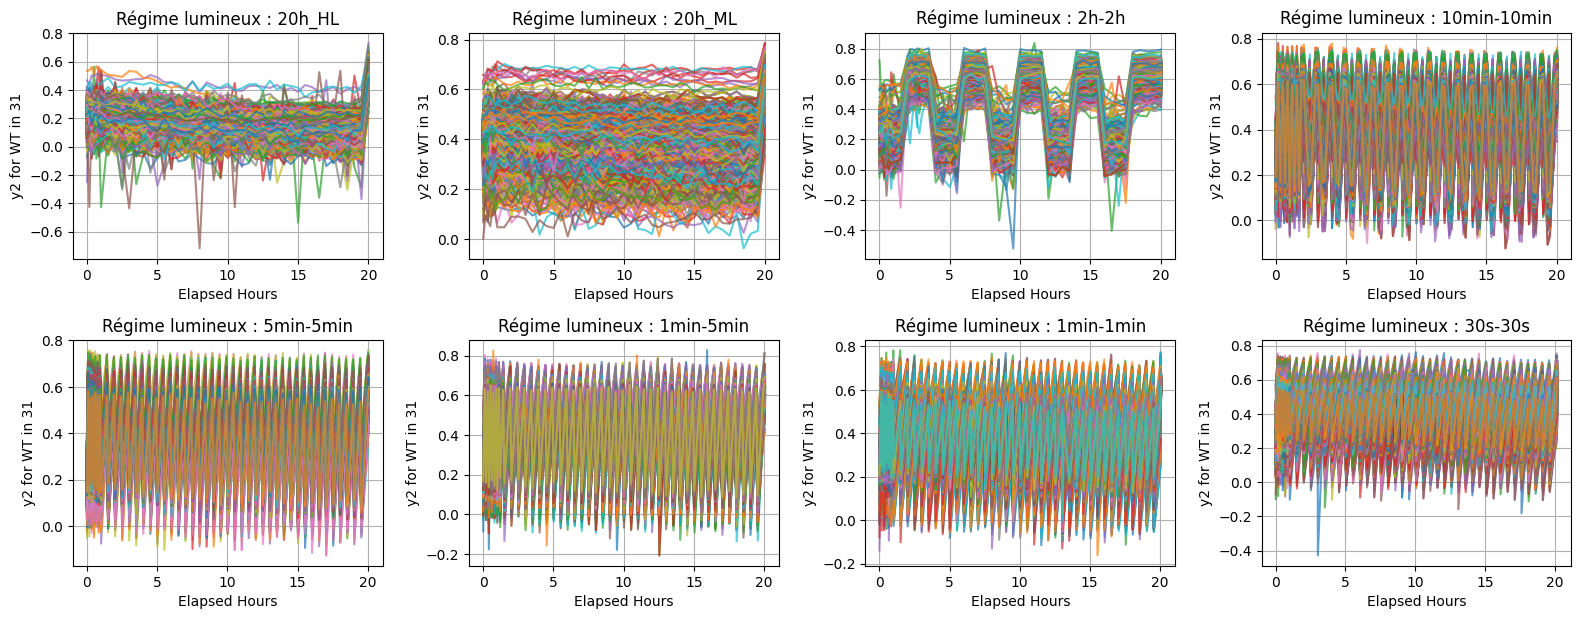

In [9]:
Plots.plot_raw_y(data, ts = 'y2', which_plate = '31', mutant = 'WT')

### Compute pairwise intra distance

In [12]:
WT_intradist = gene_self_sim.get_intra_distance_for_WT(new)
WT_intradist.drop(
    WT_intradist[WT_intradist['well_id_pair'].apply(lambda x: x[0] == x[1])].index,
    inplace=True
)
WT_intradist.drop_duplicates(inplace=True)


In [5]:
WT_intradist= pd.read_parquet('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/WT_intradist_MAY_phase2.parquet')

In [14]:
# Compter le nombre de WT par plaque et par régime lumineux
wt_count_per_plate_light_regime = WT_intradist.groupby(['plate', 'light_regime']).size()

# Afficher le nombre de WT par plaque et par régime lumineux
print("\nCount of WT per plate and light regime:")
print(wt_count_per_plate_light_regime)


Count of WT per plate and light regime:
plate  light_regime
30v1   10min-10min        21
       1min-1min          21
       1min-5min          21
       20h_HL             21
       20h_ML             21
                       ...  
99v3   1min-5min       72771
       20h_HL          72771
       20h_ML          72771
       2h-2h           71631
       30s-30s         72771
Length: 102, dtype: int64


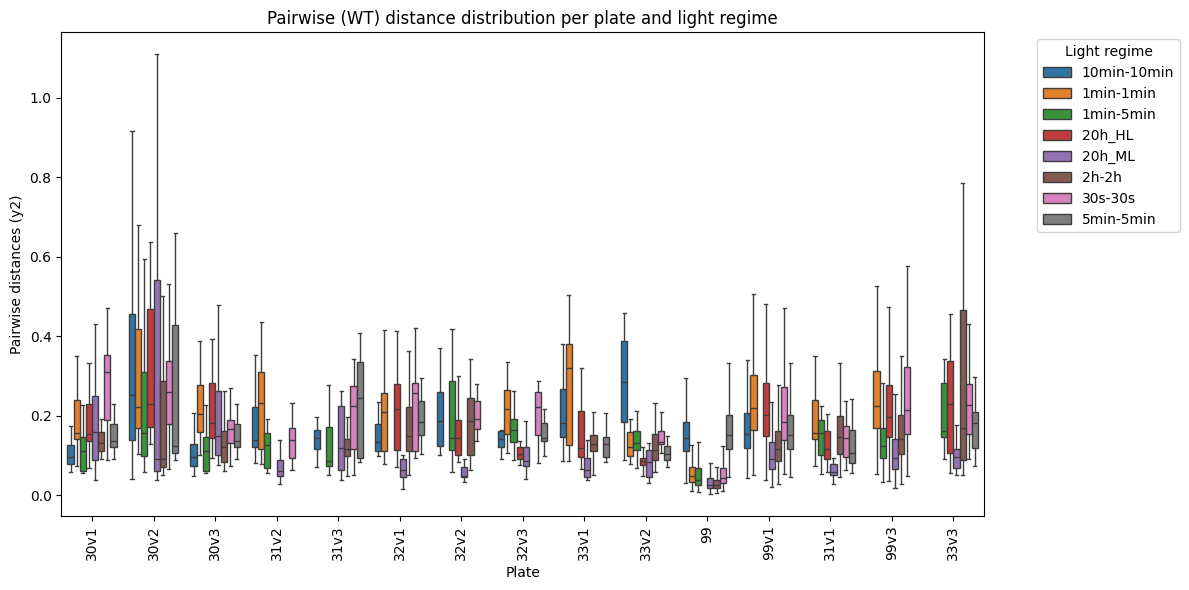

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Supposons que WT_intradist est le DataFrame contenant les distances intra-groupe
# et qu'il contient les colonnes 'plate', 'light_regime', et 'pairwise_distances_y2'

# Créer un boxplot pour visualiser la distribution des distances intra-groupe par plaque
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=WT_intradist,
    x='plate',  # Axe X : les plaques
    y='pairwise_distances_y2',  # Axe Y : les distances intra-groupe
    hue='light_regime',  # Couleur : les régimes lumineux
    showfliers=False  # Optionnel : ne pas afficher les outliers
)

plt.title("Pairwise (WT) distance distribution per plate and light regime")
plt.xlabel("Plate")
plt.ylabel("Pairwise distances (y2)")
plt.legend(title="Light regime", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Plate 15 WT in N03 is strange:

In [ ]:
#WT_intradist = WT_intradist[~((WT_intradist['plate'] == 15) & WT_intradist['well_id_pair'].apply(lambda x: 'N03' in x) & (WT_intradist['light_regime']=='10min-10min'))]


In [18]:
weird31=new[(new['plate'].str.startswith('31'))&(new['mutant_ID']=='WT')]

In [19]:
weird31.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/weird31.csv', index=False)

In [9]:
data=old

In [10]:
wt_data = data[(data['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data['start_date']>= '2024-05-19') & (data['plate'] != 20) & (data['plate'] != '20')]
wt_counts = wt_counts = wt_data.groupby(['plate', 'light_regime']).agg({
    'well_id': list,
    'mutant_ID': lambda x: list(set(x)),  # optional if all WT
    'mutated_genes': lambda x: list(set(x))
}).reset_index()

wt_counts['wt_count'] = wt_counts['well_id'].apply(len)
# wt_counts = wt_counts[['plate','light_regime', 'wt_count', 'well_id']]

is_constant = wt_counts.groupby('plate')['wt_count'].nunique().eq(1).all()
print("Nombre de WT par plaque et par régime lumineux :")
print(wt_counts)


Nombre de WT par plaque et par régime lumineux :
Empty DataFrame
Columns: [plate, light_regime, well_id, mutant_ID, mutated_genes, wt_count]
Index: []


In [53]:
wt_counts.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/WT_counts_4-30_phase2.csv')

In [29]:
new.drop_duplicates(inplace=True)

# Obvious disregards

In [ ]:
WT_intradist=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/WT_intradist.csv')


/tmp/ipykernel_1678155/3329572478.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  WT_intradist=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/WT_intradist.csv')


In [ ]:
dist31 = max(WT_intradist[WT_intradist['plate']=='30v3']['pairwise_distances_y2'])
dist31

In [ ]:
# Filtrer les plaques avec pairwise_distances_y2 > 5
filtered_plates = WT_intradist[WT_intradist['pairwise_distances_y2'] > 3.5]
filtered_plates = filtered_plates.drop_duplicates()
# Afficher les plaques et les régimes lumineux correspondants
result = filtered_plates[['plate', 'light_regime', 'pairwise_distances_y2', 'well_id_pair', 'mean_intra_distance_y2']]

# Afficher les résultats
print(result)

# Si vous voulez les plaques uniques
unique_plates = result['plate'].unique()
print(f"mean_intra_distance_y2 > 1: {unique_plates}")

         plate light_regime  pairwise_distances_y2 well_id_pair  \
660884    31v2  10min-10min               4.378298   (C03, I02)   
660908    31v2  10min-10min               3.741384   (C03, N13)   
661061    31v2  10min-10min               3.590524   (C12, H14)   
661064    31v2  10min-10min               4.857956   (C12, I02)   
661076    31v2  10min-10min               3.894985   (C12, M12)   
...        ...          ...                    ...          ...   
10341224  31v3    5min-5min               7.081232   (L03, N22)   
10341284  31v3    5min-5min               5.566415   (N03, O07)   
10341365  31v3    5min-5min               6.439158   (N12, O07)   
10341392  31v3    5min-5min               7.365090   (N22, O07)   
10341410  31v3    5min-5min               3.583555   (O02, O07)   

          mean_intra_distance_y2  
660884                   1.45603  
660908                   1.45603  
661061                   1.45603  
661064                   1.45603  
661076              

In [ ]:
#result.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/WT_intradist_31.csv', index=False)

# Choosing the closest 3 WT in each plate

In [11]:
WT_intradist=pd.read_parquet('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/WT_intradist_phase1.parquet')

In [5]:
import pandas as pd
import numpy as np

# Calculer la différence absolue entre la distance intra-groupe et la moyenne
WT_intradist['distance_to_mean'] = np.abs(WT_intradist['pairwise_distances_y2'] - WT_intradist['mean_intra_distance_y2'])

# Trier les données par plaque, série temporelle et distance à la moyenne
WT_intradist_sorted = WT_intradist.sort_values(by=['plate', 'light_regime', 'distance_to_mean'])

# Sélectionner les 3 WT les plus proches de la moyenne pour chaque plaque et série temporelle
closest_3_WT = WT_intradist_sorted.groupby(['plate', 'light_regime']).head(3)

# Afficher le résultat
print(closest_3_WT)

# Sauvegarder le résultat dans un fichier CSV si nécessaire
# closest_3_WT.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/closest_3_WT.csv', index=False)

        light_regime plate well_id_pair  pairwise_distances_y2  \
14       10min-10min  30v1   [C22, N22]               0.106374   
7        10min-10min  30v1   [C12, H12]               0.103932   
13       10min-10min  30v1   [C22, N12]               0.101060   
146120     1min-1min  30v1   [C12, N22]               0.191788   
146126     1min-1min  30v1   [H12, N12]               0.191280   
...              ...   ...          ...                    ...   
1090273        2h-2h  99v3   [M20, N02]               0.167720   
1052767        2h-2h  99v3   [E03, J03]               0.167713   
1300738      30s-30s  99v3   [J22, M15]               0.280774   
1250389      30s-30s  99v3   [B10, J24]               0.280769   
1262018      30s-30s  99v3   [C21, L20]               0.280762   

         pairwise_distances_ynpq  mean_intra_distance_y2  total_wt_cells  \
14                      0.032849                0.106873               7   
7                       0.030078                0.10687

In [6]:
import pandas as pd
import numpy as np
from itertools import combinations

# Calculer la différence absolue entre la distance intra-groupe et la moyenne
WT_intradist['distance_to_mean'] = np.abs(WT_intradist['pairwise_distances_y2'] - WT_intradist['mean_intra_distance_y2'])
#WT_intradist = WT_intradist.drop_duplicates()

# Initialiser une liste pour stocker les résultats
closest_3_WT_list = []


# Grouper par plaque et régime lumineux
for (plate, light_regime), group in WT_intradist.groupby(['plate', 'light_regime']):
    # Extraire les well_id_pairs et les distances

    well_id_pairs = group['well_id_pair'].apply(lambda x: tuple(x))#.apply(eval).tolist()  # Convertir les chaînes en tuples
    distances = group['pairwise_distances_y2'].tolist()
    
    # Créer un dictionnaire pour stocker les distances entre chaque paire
    pairwise_distances = {tuple(sorted(pair)): dist for pair, dist in zip(well_id_pairs, distances)}
    
    # Identifier les 3 WT les plus proches les uns des autres
    unique_wells = sorted(set(well for pair in well_id_pairs for well in pair))
    if len(unique_wells) < 3:
        print(f"⚠️ Skipped {plate} - {light_regime} (only {len(unique_wells)} WT pairs found)")

    closest_triplet = None
    min_total_distance = float('inf')
    
    # Tester toutes les combinaisons de triplets
    for triplet in combinations(unique_wells, 3):
        # Calculer la somme des distances intra-paires pour le triplet
        # Lookup using sorted triplet pairs
        total_distance = (
            pairwise_distances.get(tuple(sorted((triplet[0], triplet[1]))), float('inf')) +
            pairwise_distances.get(tuple(sorted((triplet[0], triplet[2]))), float('inf')) +
            pairwise_distances.get(tuple(sorted((triplet[1], triplet[2]))), float('inf'))
        )
        # Mettre à jour si une meilleure combinaison est trouvée
        if total_distance < min_total_distance:
            min_total_distance = total_distance
            closest_triplet = triplet
    
    # Ajouter le résultat pour cette plaque et ce régime lumineux
    if closest_triplet:
        closest_3_WT_list.append({
            'plate': plate,
            'light_regime': light_regime,
            'closest_wells': closest_triplet,
            'total_distance': min_total_distance
        })

# Convertir les résultats en DataFrame
closest_3_WT_df = pd.DataFrame(closest_3_WT_list)

# Afficher le résultat
print(closest_3_WT_df)

# Sauvegarder le résultat dans un fichier CSV si nécessaire
#closest_3_WT_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/closest_3_WT_triplets.csv', index=False)

    plate light_regime    closest_wells  total_distance
0    30v1  10min-10min  (C03, C12, N03)        0.191478
1    30v1    1min-1min  (C12, C22, H12)        0.327977
2    30v1    1min-5min  (C22, N12, N22)        0.177490
3    30v1       20h_HL  (C12, H12, N03)        0.303721
4    30v1       20h_ML  (C12, H12, N03)        0.146798
..    ...          ...              ...             ...
97   99v3    1min-5min  (J07, J09, L07)        0.105544
98   99v3       20h_HL  (A14, D14, M06)        0.156692
99   99v3       20h_ML  (D07, G03, N03)        0.065995
100  99v3        2h-2h  (E09, E12, G09)        0.096588
101  99v3      30s-30s  (G09, J05, J14)        0.161517

[102 rows x 4 columns]


In [6]:
closest_3_WT_df=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/closest_3_WT_triplets_MAY-PHASE2.csv', index=False)

TypeError: read_csv() got an unexpected keyword argument 'index'

In [15]:
closest_3_WT_df['plate'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 20, 21, 22, 23, 99])

In [9]:
from itertools import combinations

result = []

for (plate, light_regime), group in WT_intradist.groupby(['plate', 'light_regime']):
    # Convert well_id_pair to tuple if it's a list
    well_id_pairs = group['well_id_pair'].apply(tuple)
    distances = group['pairwise_distances_y2'].values

    # Build distance dictionary with symmetric entries
    dist_dict = {}
    for (pair, dist) in zip(well_id_pairs, distances):
        a, b = pair
        dist_dict[(a, b)] = dist
        dist_dict[(b, a)] = dist  # Ensure symmetry

    # Get all unique well IDs
    unique_wells = set([w for pair in well_id_pairs for w in pair])

    best_triplet = None
    min_dist = float('inf')

    for triplet in combinations(unique_wells, 3):
        a, b, c = triplet
        if (a, b) in dist_dict and (a, c) in dist_dict and (b, c) in dist_dict:
            total = dist_dict[(a, b)] + dist_dict[(a, c)] + dist_dict[(b, c)]
            if total < min_dist:
                min_dist = total
                best_triplet = (a, b, c)

    if best_triplet:
        result.append({
            'plate': plate,
            'light_regime': light_regime,
            'closest_wells': best_triplet,
            'total_distance': min_dist
        })

# Convert to DataFrame
closest_3_WT_df = pd.DataFrame(result)
print(closest_3_WT_df)
# Optionally save
# closest_3_WT_df.to_csv('closest_3_WT_triplets.csv', index=False)


    plate light_regime    closest_wells  total_distance
0    30v1  10min-10min  (N03, C03, C12)        0.191478
1    30v1    1min-1min  (C22, H12, C12)        0.327977
2    30v1    1min-5min  (C22, N12, N22)        0.177490
3    30v1       20h_HL  (H12, N03, C12)        0.303721
4    30v1       20h_ML  (H12, N03, C12)        0.146798
..    ...          ...              ...             ...
97   99v3    1min-5min  (L07, J09, J07)        0.105544
98   99v3       20h_HL  (D14, A14, M06)        0.156692
99   99v3       20h_ML  (G03, N03, D07)        0.065995
100  99v3        2h-2h  (G09, E09, E12)        0.096588
101  99v3      30s-30s  (G09, J14, J05)        0.161517

[102 rows x 4 columns]


In [ ]:
# # Uniformiser le type de la colonne 'plate' dans les deux DataFrames
# result_df['plate'] = result_df['plate'].astype(str)
# closest_3_WT_df['plate'] = closest_3_WT_df['plate'].astype(str)

# # Filtrer result_df pour les plaques entre 1 et 24 et convertir en int
# result_df_filtered = result_df[
#     result_df['plate'].str.match(r'^\d+$')  # Vérifie que la plaque contient uniquement des chiffres
# ]
# result_df_filtered = result_df_filtered[
#     (result_df_filtered['plate'].astype(int) >= 1) & 
#     (result_df_filtered['plate'].astype(int) <= 24)
# ]
# result_df_filtered['plate'] = result_df_filtered['plate'].astype(int)  # Convertir en int

# # Filtrer closest_3_WT_df pour les plaques commençant par '30', '31', '32', '33'
# closest_3_WT_filtered = closest_3_WT_df[
#     closest_3_WT_df['plate'].str.startswith(('30', '31', '32', '33'))
# ]

# # Harmoniser les colonnes pour la concaténation
# result_df_filtered = result_df_filtered.rename(columns={'well_ids': 'closest_wells'})
# result_df_filtered = result_df_filtered[['plate', 'light_regime', 'closest_wells']]

# closest_3_WT_filtered = closest_3_WT_filtered[['plate', 'light_regime', 'closest_wells']]

# # Concaténer les deux DataFrames
# final_df = pd.concat([result_df_filtered, closest_3_WT_filtered], ignore_index=True)

# # Afficher les plaques uniques
# print(final_df['plate'].unique())

# # Sauvegarder le résultat dans un fichier CSV si nécessaire
# final_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/3_WT.csv', index=False)

[1 2 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 20 21 22 23 4 '30v1' '30v2'
 '30v3' '31v1' '31v2' '31v3' '32v1' '32v2' '32v3' '33v1' '33v2' '33v3']


In [ ]:
WT_Wells = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/3_WT.csv')

,plate,light_regime,closest_wells
0,1,10min-10min,"[A03, A02, A04]"
1,2,10min-10min,"[N03, N22, C12]"
2,3,10min-10min,"[N03, N22, C12]"
3,5,10min-10min,"[N03, N22, C12]"
4,6,10min-10min,"[N03, N22, C12]"
...,...,...,...
202,33v3,20h_HL,"(C12, H12, N03)"
203,33v3,20h_ML,"(C12, H12, N03)"
204,33v3,2h-2h,"(C03, C12, N12)"
205,33v3,30s-30s,"(C03, C12, N12)"


# Normalization 2/3 (only WTs by WTs)


In [ ]:
import pandas as pd

# Charger les données
data = new
data['nullWT'] = False

# WT/WT CLiP dans les plates 3+
data_30sWT = data[data['plate'].str.startswith('3') & (data['mutant_ID'].isin(['WT', 'WT CLiP']))]
reference = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/closest_3_WT_triplets_MAY-PHASE2.csv')

# Colonnes y2
y2_columns = [col for col in data_30sWT.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

# Parcourir chaque plaque et régime lumineux
for _, row in reference.iterrows():
    plate = row['plate']
    light_regime = row['light_regime']
    closest_wells = eval(row['closest_wells'])
    
    subset = data_30sWT[
        (data_30sWT['plate'] == plate) &
        (data_30sWT['light_regime'] == light_regime) &
        (data_30sWT['well_id'].isin(closest_wells))
    ]
    
    if len(subset) == 3:
        subset = subset.reset_index()
        WT_1 = subset.iloc[0]
        WT_2 = subset.iloc[1]
        WT_3 = subset.iloc[2]

        mean_wt2_wt3 = (WT_2[y2_columns] + WT_3[y2_columns]) / 2

        for col in y2_columns:
            data.loc[
                (data['plate'] == plate) &
                (data['light_regime'] == light_regime) &
                (data['well_id'] == WT_1['well_id']),
                col
            ] -= mean_wt2_wt3[col]

        data.loc[
            (data['plate'] == plate) &
            (data['light_regime'] == light_regime) &
            (data['well_id'] == WT_1['well_id']),
            'nullWT'
        ] = True

# Sauvegarder
#data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_phase2.csv', index=False) 


In [13]:
# Vérifier que nullWT est correctement défini
print(data['nullWT'].value_counts())  # Devrait montrer le nombre de True et False
print(data[data['nullWT'] == True]['plate'].unique())  # Devrait inclure uniquement les plaques dans reference

nullWT
False    50467
True       971
Name: count, dtype: int64
['99' '30v1' '30v2' '30v3' '31v1' '32v1' '31v2' '32v2' '31v3' '32v3'
 '33v1' '33v2' '33v3']


In [19]:
# Filtrer les lignes WT ou WT CLiP
wt_data = data[data['mutant_ID'].isin(['WT', 'WT CLiP'])]

# Grouper par plaque et régime lumineux
grouped = wt_data.groupby(['plate', 'light_regime', 'nullWT'])

# Compter les occurrences
counts = grouped.size().reset_index(name='count')

# Pivot pour voir True/False côte à côte
pivot = counts.pivot_table(index=['plate', 'light_regime'], 
                           columns='nullWT', 
                           values='count', 
                           fill_value=0).reset_index()

# Renommer les colonnes pour plus de clarté
pivot.columns.name = None
pivot = pivot.rename(columns={True: 'nullWT_True', False: 'nullWT_False'})

# Ajouter colonne total WT par (plate, light_regime)
pivot['total_WT'] = pivot['nullWT_True'] + pivot['nullWT_False']

pivot.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/nullWT_countsphase1.csv', index=False)

In [10]:
# Filtrer les données pour la plaque '99'
data_plate_99 = data[data['plate']=='99']#.astype(str).str.startswith('99')]
# Parcourir chaque régime lumineux
for light_regime in data_plate_99['light_regime'].unique():
    # Filtrer les données pour le régime lumineux
    data_light = data_plate_99[data_plate_99['light_regime'] == light_regime]
    
    # Diviser les données en groupes de 3
    for i in range(0, len(data_light), 3):
        group = data_light.iloc[i:i+3]
        
        # Vérifier qu'il y a exactement 3 échantillons dans le groupe
        if len(group) == 3:
            # Identifier les 3 échantillons
            sample_1 = group.iloc[0]
            sample_2 = group.iloc[1]
            sample_3 = group.iloc[2]
            
            # Calculer la moyenne des valeurs y2 des deux premiers échantillons
            mean_y2 = (sample_1[y2_columns] + sample_2[y2_columns]) / 2
            
            # Normaliser les valeurs y2 du troisième échantillon
            for col in y2_columns:
                data.loc[sample_3.name, col] -= mean_y2[col]
            
            # Marquer le troisième échantillon comme 'nullWT'
            data.loc[sample_3.name, 'nullWT'] = True

# Sauvegarder les résultats
#data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE1.csv', index=False)

## Plot the NORMALISED 1/3 ON 99
the file ClaireNorm has these the wt plates normalised (99, '99', '99v..')

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm.csv')

# Filtrer les colonnes y2_1 à y2_80
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

# Obtenir les régimes lumineux uniques
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

# Créer une grille 4x4 pour les graphiques
fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # 4x4 grille
axes = axes.flatten()  # Aplatir la grille pour un accès facile

# Tracer les graphiques pour chaque régime lumineux
for i, light in enumerate(light_regimes):
    ax = axes[i]  # Sélectionner l'axe correspondant
    data_light = data[(data['light_regime'] == light) & (data['plate']=='99')]#.astype(str).str.startswith('98v'))]#.isin(['99',99]))]#)]  # Filtrer les données pour le régime lumineux actuel

    # Suivi des plaques déjà étiquetées
    labeled_plates = set()
    
    # Tracer les courbes pour chaque plaque
    for plate in data_light['plate'].unique():
        data_plate = data_light[(data['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data_light['plate'] == plate) & (data_light['nullWT'] == True)]
        
        # Tracer chaque ligne de données y2 pour la plaque
        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].values  # Extraire les valeurs y2
            
            # Ajouter un label uniquement si la plaque n'a pas encore été étiquetée
            if plate not in labeled_plates:
                ax.plot(range(1, len(y2_columns) + 1), y2_values, alpha=0.7, label=f'Plate {plate}')
                labeled_plates.add(plate)  # Marquer la plaque comme étiquetée
            else:
                ax.plot(range(1, len(y2_columns) + 1), y2_values, alpha=0.7)  # Pas de label
    
    # Ajouter des détails au graphique
    #axes[i].set_xlim(0, 10)
    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Y2 for 98v[1,2,3]WT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

# Supprimer les axes inutilisés si moins de 16 régimes lumineux
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm.csv'

/tmp/ipykernel_543086/3881869286.py:6: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE2.csv')
/tmp/ipykernel_543086/3881869286.py:45: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(y, axis=0)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_543086/3881869286.py:45: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(y, axis=0)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_543086/3881869286.py:45: RuntimeWarning: Mean of empty slice
  me

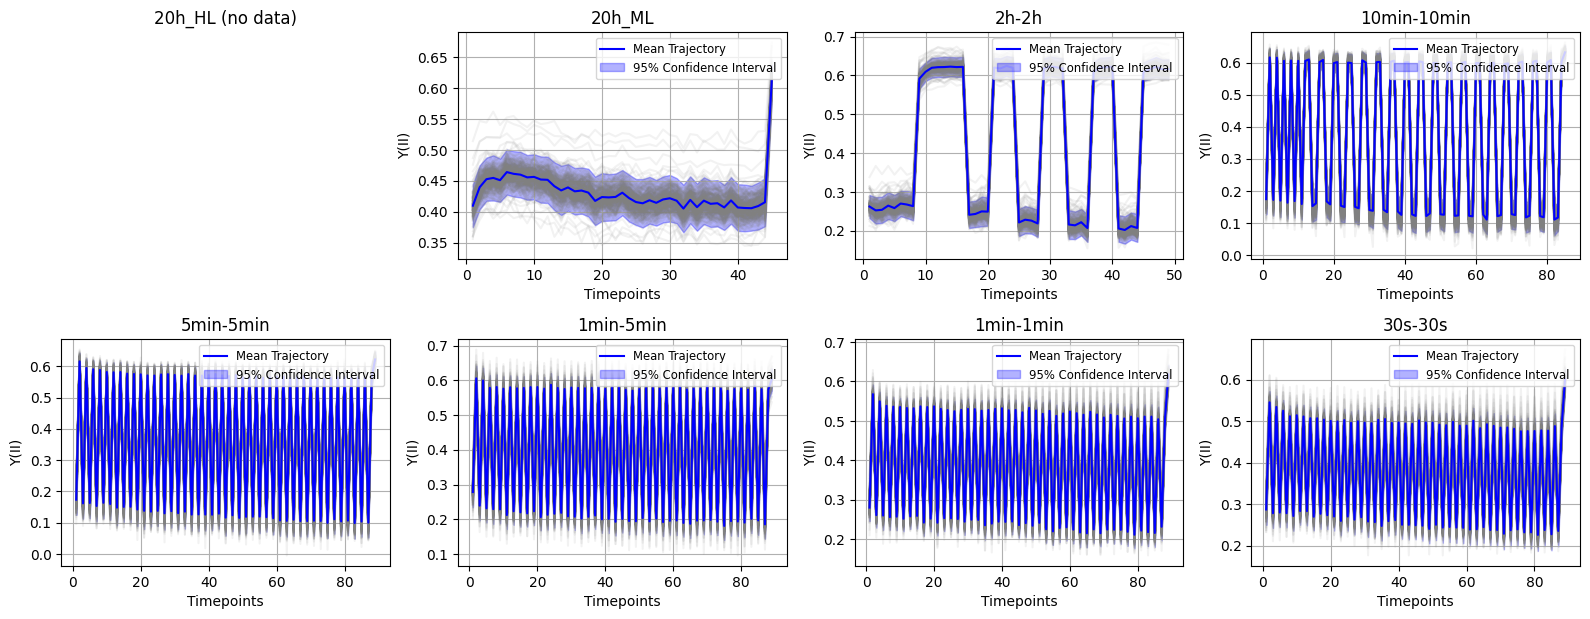

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger les données
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE2.csv')

# Colonnes y2
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
x = np.arange(1, len(y2_columns) + 1)

# Régimes lumineux
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

# Grille
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

# Couleur unique
color = 'blue'

for i, light in enumerate(light_regimes):
    ax = axes[i]

    # Filtrer les données : plaque 99, WT, régime lumineux
    subset = data[
        (data['light_regime'] == light) &
        (data['plate'] == '99') &
        (data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (data['nullWT'] == False)
    ]

    if subset.empty:
        ax.set_title(f'{light} (no data)')
        ax.axis('off')
        continue

    y = subset[y2_columns].astype(float).values

    # Traces individuelles
    for row in y:
        ax.plot(x, row, color='gray', alpha=0.1)

    # Moyenne et intervalle de confiance à 95%
    mean = np.nanmean(y, axis=0)
    std = np.nanstd(y, axis=0)
    n = y.shape[0]
    z = norm.ppf(1 - 0.05/2)
    ci95 = z * std# / np.sqrt(n)      !!! Careful if you want uncertainty of the mean or individual samples

    ax.plot(x, mean, color=color, label='Mean Trajectory')
    ax.fill_between(x, mean - ci95, mean + ci95, color=color, alpha=0.3, label='95% Confidence Interval')

    ax.set_title(f'{light}')
    ax.set_xlabel('Timepoints')
    ax.set_ylabel('Y(II)')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

# Supprimer les cases vides
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### Slopes for the nullWTs

In [11]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# Charger les données
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE1.csv')
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
data[y2_columns] = data[y2_columns].apply(pd.to_numeric, errors='coerce')

elapsed_hours = np.array([float(col.split('_')[-1]) for col in y2_columns]).reshape(-1, 1)

data['y2_slope'] = np.nan

normalised_wts = data[data['nullWT'] == True]

# Calculer les pentes pour chaque WT normalisé
for idx, row in normalised_wts.iterrows():
    y2_values = row[y2_columns].values.astype(float)
    valid_indices = ~np.isnan(y2_values)
    y2_values_valid = y2_values[valid_indices]
    elapsed_hours_valid = elapsed_hours[valid_indices]
    
    if len(y2_values_valid) > 1:  # Au moins 2 points nécessaires
        # Effectuer une régression linéaire
        model = LinearRegression()
        model.fit(elapsed_hours_valid.reshape(-1, 1), y2_values_valid.reshape(-1, 1))
        
        # Récupérer la pente
        slope = model.coef_[0][0]
        
        # Ajouter la pente dans la colonne 'y2_slope'
        data.loc[idx, 'y2_slope'] = slope
        print(f"Processed index {idx}, slope: {slope}")
    else:
        print(f"Skipped index {idx} due to insufficient valid points")
# Sauvegarder les résultats
#data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE1_with_slopes.csv', index=False)

Processed index 2, slope: 2.519523070240947e-05
Processed index 5, slope: -4.798323947254139e-06
Processed index 8, slope: 4.731560731085968e-05
Processed index 11, slope: -6.721399243658346e-05
Processed index 14, slope: -1.6500130196748955e-05
Processed index 17, slope: -8.980356436918638e-06
Processed index 20, slope: -3.657493120855492e-05
Processed index 23, slope: -7.640919805908074e-05
Processed index 26, slope: -5.139861994680741e-05
Processed index 29, slope: -2.7781261660306063e-05
Processed index 32, slope: 2.4120704538003505e-05
Processed index 35, slope: -7.32575596790016e-05
Processed index 38, slope: 2.902067840528758e-05
Processed index 41, slope: 2.293162037308467e-05
Processed index 44, slope: -4.502097932468097e-05
Processed index 47, slope: 8.38936001367166e-05
Processed index 50, slope: -5.842766328584158e-05
Processed index 53, slope: -4.140948795559577e-06
Processed index 56, slope: 0.00010194650678472718
Processed index 59, slope: -3.702335917456948e-05
Processe

### Slope distributions for the nullWT

/tmp/ipykernel_1615532/375926093.py:4: DtypeWarning: Columns (463,464) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')


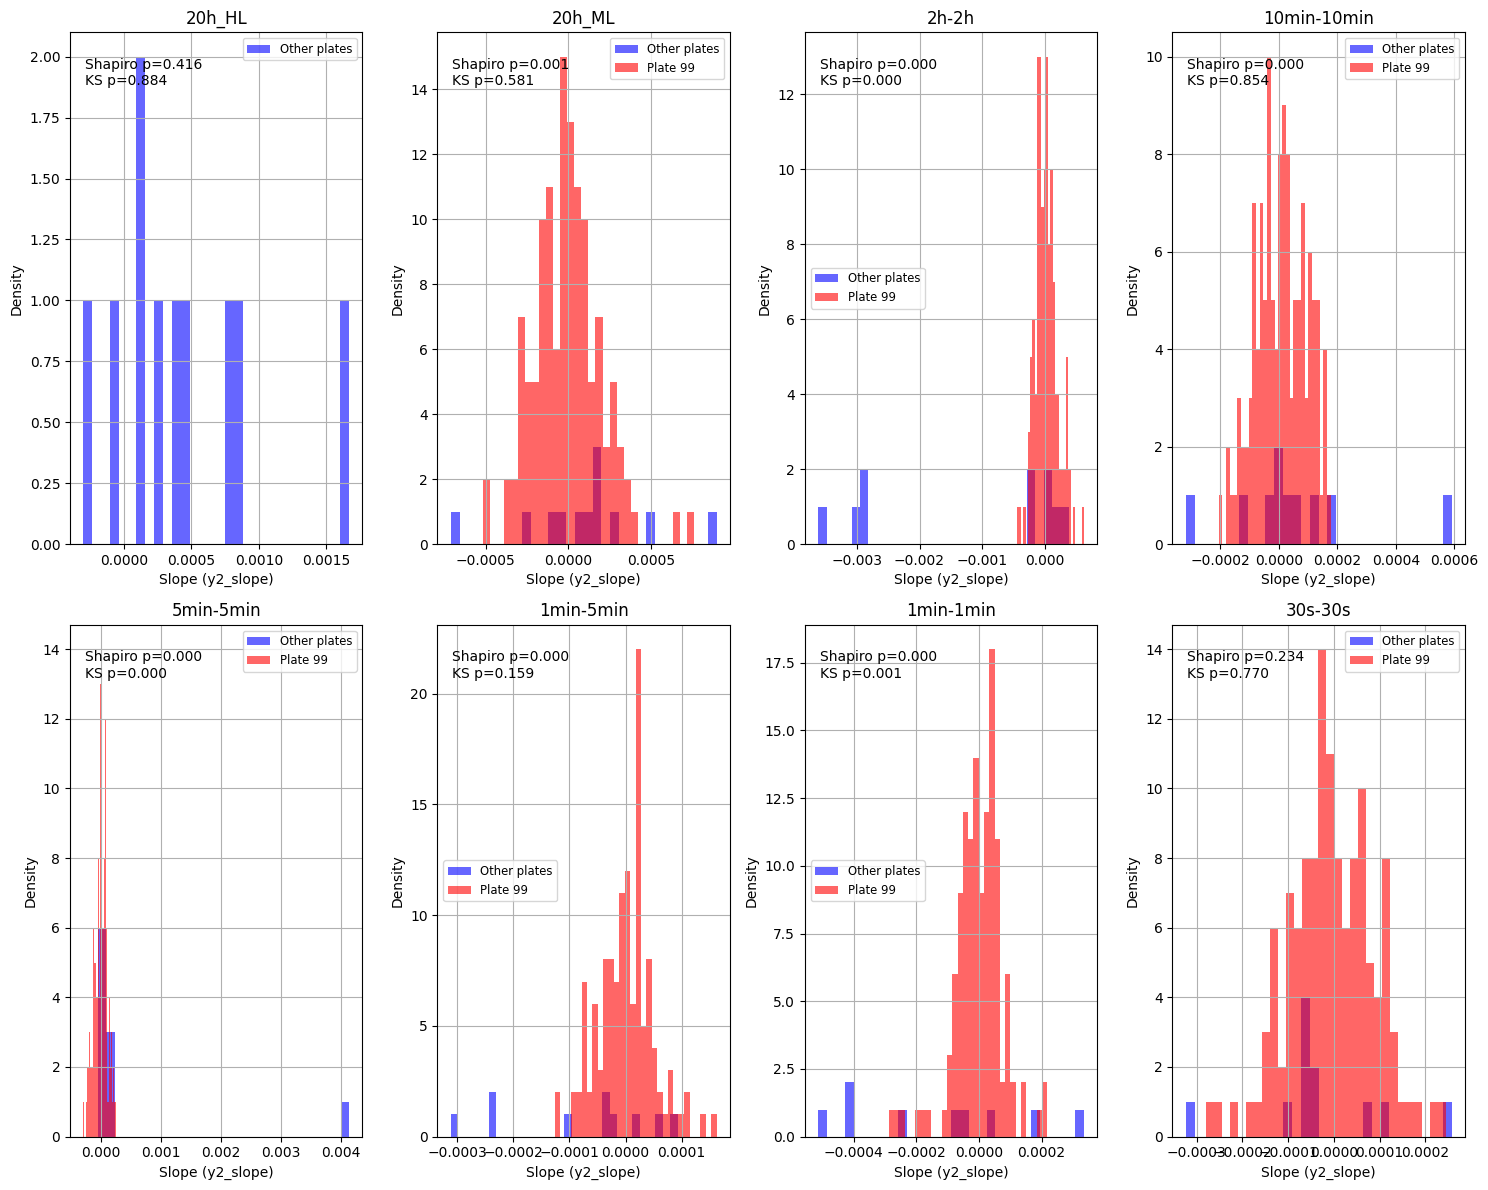

In [17]:
from scipy.stats import norm, shapiro, kstest
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')
# Filtrer les WT normalisés (nullWT == True)
normalised_wts = data[(data['nullWT'] == True)]# & (data['plate']!='99')]

# Obtenir les régimes lumineux uniques
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']


# Définir la taille de la grille (par exemple, 3x3 pour 9 régimes lumineux)
n_rows = 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()  # Aplatir la grille pour un accès facile

# Parcourir chaque régime lumineux
for i, light_regime in enumerate(light_regimes):
    ax = axes[i]  # Sélectionner l'axe correspondant
    # Filtrer les données pour le régime lumineux
    data_light = normalised_wts[normalised_wts['light_regime'] == light_regime]
    
    # Extraire les pentes (y2_slope)
    # slopes = data_light['y2_slope'].dropna()
    slopes_99 = data_light[data_light['plate'] == '99']['y2_slope'].dropna()
    slopes_other = data_light[data_light['plate'] != '99']['y2_slope'].dropna()
    
    # Vérifier si des pentes sont disponibles
    if slopes_99.empty and slopes_other.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(f'{light_regime}')
        ax.axis('off')
        continue

    # Histogrammes superposés
    if not slopes_other.empty:
        ax.hist(slopes_other, bins=30, alpha=0.6, color='blue', label='Other plates')

    if not slopes_99.empty:
        ax.hist(slopes_99, bins=30, alpha=0.6, color='red', label='Plate 99')

    # Tester la normalité sur toutes les données combinées (si tu veux garder ce test global)
    slopes_combined = pd.concat([slopes_99, slopes_other])
    mean, std = norm.fit(slopes_combined)
    shapiro_stat, shapiro_p = shapiro(slopes_combined)
    ks_stat, ks_p = kstest(slopes_combined, 'norm', args=(mean, std))

    # Ajouter résultats de normalité
    ax.text(0.05, 0.95, f'Shapiro p={shapiro_p:.3f}\nKS p={ks_p:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top')

    
    # Ajouter des détails au graphique
    ax.set_title(f'{light_regime}')
    ax.set_xlabel('Slope (y2_slope)')
    ax.set_ylabel('Density')
    ax.legend(fontsize='small')
    ax.grid(True)

# Supprimer les axes inutilisés si le nombre de régimes lumineux est inférieur au nombre de sous-graphiques
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

In [6]:
from scipy.stats import ks_2samp
import pandas as pd
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE2_mutants&WT_with_slopes.csv')

# Stock results
results = []

# Loop through light regimes
for regime in data['light_regime'].unique():
    group_99 = data[
        (data['plate'] == '99') &
        (data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (data['nullWT'] == True) &
        (data['light_regime'] == regime)
    ]['y2_slope'].dropna()

    group_3x = data[
        (data['plate']!='99') &#.astype(str).str.startswith('3')) &
        #(~data['plate'].astype(str).str.startswith('31'))&
        (data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (data['nullWT'] == True) &
        (data['light_regime'] == regime)
    ]['y2_slope'].dropna()

    if len(group_99) > 0 and len(group_3x) > 0:
        stat, p = ks_2samp(group_99, group_3x)
        results.append({
            'light_regime': regime,
            'n_plate99': len(group_99),
            'n_plate3x': len(group_3x),
            'KS_stat': stat,
            'p_value': p
        })

# Display results
ks_df = pd.DataFrame(results)


print(ks_df)



/tmp/ipykernel_1615532/1588854521.py:3: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE2_mutants&WT_with_slopes.csv')


  light_regime  n_plate99  n_plate3x   KS_stat   p_value
0    1min-1min        127          9  0.327209  0.267058
1       20h_ML        127         12  0.177165  0.818559
2        2h-2h        127         10  0.205512  0.752464
3      30s-30s        127         11  0.218325  0.642130
4    1min-5min        127          9  0.240595  0.631386
5  10min-10min        127         10  0.269291  0.433568
6    5min-5min        127          9  0.201225  0.819646


## Normalise the rest (mutants) using the 2/3 WTs

In [17]:
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE1_with_slopes.csv')
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
reference = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/closest_3_WT_triplets_MAY-PHASE2.csv')

# Colonnes y2
data_30smutants = data[(data['plate'].str.startswith('3')) & (~data['mutant_ID'].isin(['WT', 'WT CLiP']))]
data_30sWT = data[(data['plate'].str.startswith('3')) & (data['mutant_ID'].isin(['WT', 'WT CLiP']))]
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

# Parcourir chaque plaque et régime lumineux
for _, row in reference.iterrows():
    plate = row['plate']
    light_regime = row['light_regime']
    closest_wells = eval(row['closest_wells'])
    
    subset = data_30sWT[
        (data_30sWT['plate'] == plate) &
        (data_30sWT['light_regime'] == light_regime) &
        (data_30sWT['well_id'].isin(closest_wells))
    ]
    print(len(subset))
    if len(subset) == 3:
        subset = subset.reset_index()
        #WT_1 = subset.iloc[0]
        WT_2 = subset.iloc[1]
        WT_3 = subset.iloc[2]
        if (WT_2['nullWT'] or WT_3['nullWT']):
            print('Careful not nullWT')
        mean_wt2_wt3 = (WT_2[y2_columns] + WT_3[y2_columns]) / 2

        mask = (
            (data['plate'] == plate) &
            (data['light_regime'] == light_regime) &
            (~data['mutant_ID'].isin(['WT', 'WT CLiP']))
        )
        data.loc[mask, y2_columns] = data.loc[mask, y2_columns] - mean_wt2_wt3.values
            



        

3


/tmp/ipykernel_893680/2804142195.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[np.float64(-0.09100494) np.float64(-0.12934574000000001)
 np.float64(-0.08756118000000002) np.float64(-0.08756118000000002)
 np.float64(-0.07753504000000003) np.float64(-0.12934574000000001)
 np.float64(-0.07740434000000002) np.float64(-0.07740434000000002)
 np.float64(-0.11026863) np.float64(-0.05114954000000002)
 np.float64(-0.05077029000000002) np.float64(-0.05174028000000003)
 np.float64(-0.07701612000000002) np.float64(-0.061038830000000016)
 np.float64(-0.03507367) np.float64(-0.08831463)
 np.float64(-0.06560353000000002) np.float64(-0.05077029000000002)
 np.float64(-0.05077029000000002) np.float64(-0.07619331000000001)
 np.float64(-0.12975714000000002) np.float64(-0.10858618)
 np.float64(-0.04580555000000003) np.float64(-0.07829691000000003)
 np.float64(-0.05411995000000003) np.float64(-0.09880838)
 np.float64(-

3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [18]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# Charger les données
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
data[y2_columns] = data[y2_columns].apply(pd.to_numeric, errors='coerce')

elapsed_hours = np.array([float(col.split('_')[-1]) for col in y2_columns]).reshape(-1, 1)

mutants = data[~data['mutant_ID'].isin(['WT', 'WT CLiP'])]

# Calculer les pentes pour chaque WT normalisé
for idx, row in mutants.iterrows():
    y2_values = row[y2_columns].values.astype(float)
    valid_indices = ~np.isnan(y2_values)
    y2_values_valid = y2_values[valid_indices]
    elapsed_hours_valid = elapsed_hours[valid_indices]
    
    if len(y2_values_valid) > 1:  # Au moins 2 points nécessaires
        # Effectuer une régression linéaire
        model = LinearRegression()
        model.fit(elapsed_hours_valid.reshape(-1, 1), y2_values_valid.reshape(-1, 1))
        
        # Récupérer la pente
        slope = model.coef_[0][0]
        
        # Ajouter la pente dans la colonne 'y2_slope'
        data.loc[idx, 'y2_slope'] = slope
        print(f"Processed index {idx}, slope: {slope}")
    else:
        print(f"Skipped index {idx} due to insufficient valid points")
# Sauvegarder les résultats
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv', index=False)

Processed index 1915, slope: -0.0017234779483868198
Processed index 1916, slope: -0.0017234779483868198
Processed index 1917, slope: 0.00012515101534078642
Processed index 1918, slope: -0.002324434651311403
Processed index 1919, slope: -0.0008046258223265493
Processed index 1920, slope: -0.0003050556067315946
Processed index 1921, slope: -0.000683407768305662
Processed index 1922, slope: -0.00027341099411802203
Processed index 1923, slope: -0.00017116819662423973
Processed index 1924, slope: -0.0006054510692653243
Processed index 1925, slope: -0.00021150126054976474
Processed index 1926, slope: -0.00023974035214701576
Processed index 1927, slope: -0.00023974035214701576
Processed index 1928, slope: -0.00023974035214701576
Processed index 1929, slope: -0.00022321235312664864
Processed index 1930, slope: -0.00018120909012526
Processed index 1931, slope: -0.000215864190716549
Processed index 1932, slope: -0.0004943148141195274
Processed index 1933, slope: -0.000548735134222652
Processed i

### Plot the mutants (normalized)

/tmp/ipykernel_893680/3570474.py:45: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(y, axis=0)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_893680/3570474.py:45: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(y, axis=0)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_893680/3570474.py:45: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(y, axis=0)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_893680/3570474.p

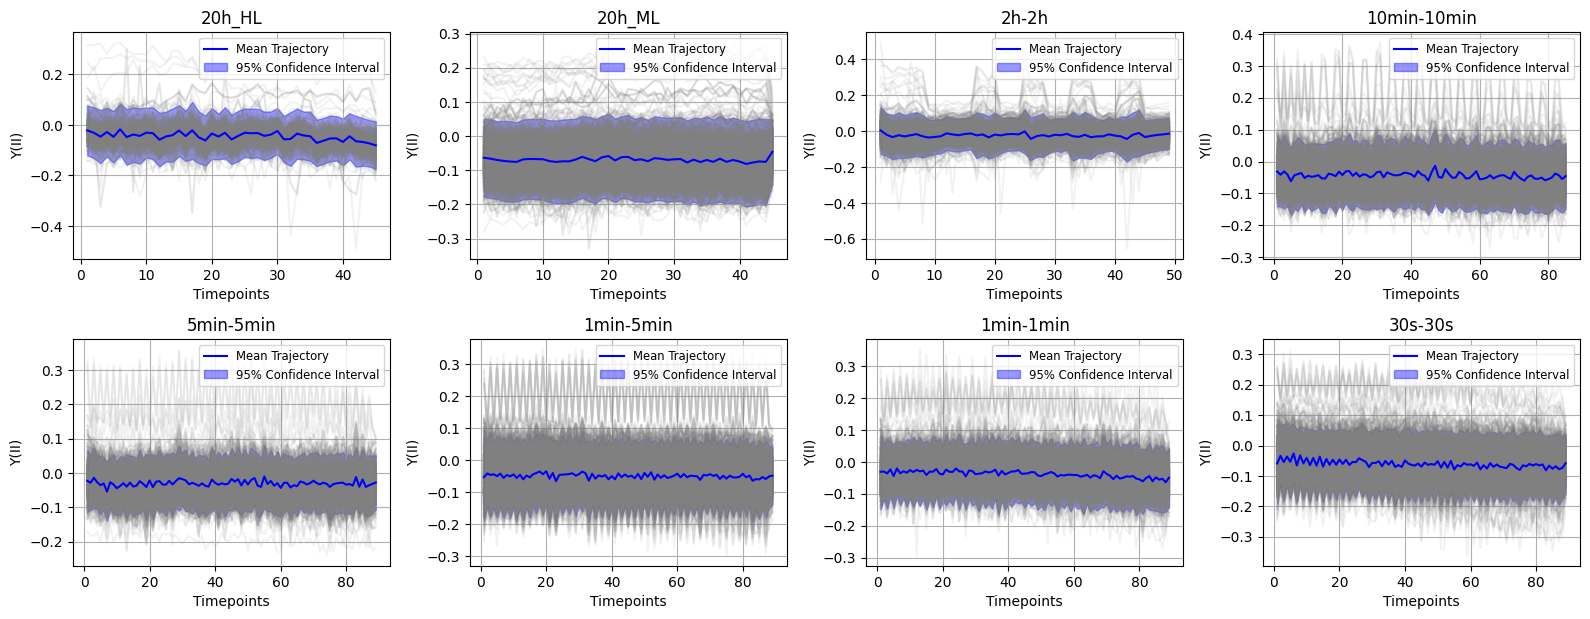

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger les données
data = mutants

# Colonnes y2
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
x = np.arange(1, len(y2_columns) + 1)

# Régimes lumineux
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

# Grille
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

# Couleur unique
color = 'blue'

for i, light in enumerate(light_regimes):
    ax = axes[i]

    # Filtrer les données : plaque 99, WT, régime lumineux
    subset = data[
        (data['light_regime'] == light) &
        (data['plate'].astype(str).str.startswith('31')) &
        #(data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (data['nullWT'] == False)
    ]

    if subset.empty:
        ax.set_title(f'{light} (no data)')
        ax.axis('off')
        continue

    y = subset[y2_columns].astype(float).values

    # Traces individuelles
    for row in y:
        ax.plot(x, row, color='gray', alpha=0.1)

    # Moyenne et intervalle de confiance à 95%
    mean = np.nanmean(y, axis=0)
    std = np.nanstd(y, axis=0)
    n = y.shape[0]
    z = norm.ppf(1 - 0.05/2)
    ci95 = z * std# / np.sqrt(n)      !!! Careful if you want uncertainty of the mean or individual samples

    ax.plot(x, mean, color=color, label='Mean Trajectory')
    ax.fill_between(x, mean - ci95, mean + ci95, color=color, alpha=0.4, label='95% Confidence Interval')

    ax.set_title(f'{light}')
    ax.set_xlabel('Timepoints')
    ax.set_ylabel('Y(II)')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

# Supprimer les cases vides
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
